# Packages 

In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
import seaborn
from sklearn import linear_model
from matplotlib import style
%matplotlib inline

# Raw data

In [2]:
df = pd.read_csv('results.csv')
df.drop(columns=['Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7'], inplace=True)
df

,PSQI,K10,GPA
0,8,26,3.3
1,16,39,3.3
2,8,26,3.3
3,6,23,3.0
4,8,26,3.3
5,8,26,3.3
6,8,25,3.3
7,8,26,3.3
8,8,26,3.3
9,3,12,3.1


In [3]:
df[(df['GPA'] <= 3.0)].count()

PSQI    5
K10     5
GPA     5
dtype: int64

# Statistics

In [4]:
bins = [-1, 7, 14, np.inf]
labels=['1-7','8-14','>14']
df_PSQI = df.groupby(pd.cut(df['PSQI'], bins=bins, labels=labels)).size().reset_index(name='count')
df_PSQI['%'] = (df_PSQI['count'] / 50) * 100 
df_PSQI

,PSQI,count,%
0,1-7,12,24.0
1,8-14,37,74.0
2,>14,1,2.0


In [5]:
df[df['PSQI'] > 8].mean()

PSQI    11.00
K10     32.80
GPA      3.22
dtype: float64

In [6]:
bins = [-1, 19, 24, 29, np.inf]
labels=['<20','20-24','25-29', '>30']
df_K10 = df.groupby(pd.cut(df['K10'], bins=bins, labels=labels)).size().reset_index(name='count')
df_K10['%'] = (df_K10['count'] / 50) * 100 
df_K10

,K10,count,%
0,<20,9,18.0
1,20-24,3,6.0
2,25-29,29,58.0
3,>30,9,18.0


In [7]:
bins = [-1, 3.0, 3.5, np.inf]
labels=['0-3.0','3.1-3.5','>3.5']
df_GPA = df.groupby(pd.cut(df['GPA'], bins=bins, labels=labels)).size().reset_index(name='count')
df_GPA['%'] = (df_GPA['count'] / 50) * 100 
df_GPA

,GPA,count,%
0,0-3.0,5,10.0
1,3.1-3.5,39,78.0
2,>3.5,6,12.0


In [8]:
df.describe()

,PSQI,K10,GPA
count,50.000000,50.000000,50.000000
mean,7.860000,25.860000,3.286000
std,2.347469,6.995655,0.245789
min,2.000000,12.000000,2.300000
25%,8.000000,25.000000,3.300000
50%,8.000000,26.000000,3.300000
75%,8.000000,26.750000,3.300000
max,16.000000,47.000000,3.900000


# Pearson Correlation

In [9]:
df.corr()

,PSQI,K10,GPA
PSQI,1.000000,0.610204,0.176923
K10,0.610204,1.000000,-0.284832
GPA,0.176923,-0.284832,1.000000


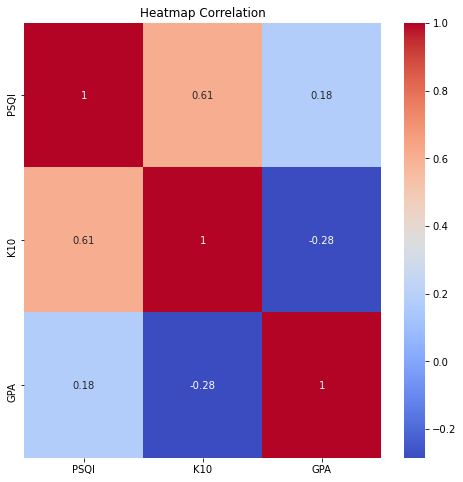

In [10]:
plt.figure(figsize=(8,8))
seaborn.heatmap(df.corr(), annot=True, cmap="coolwarm").set_title('Heatmap Correlation')
plt.savefig('heatmap_corr.png')

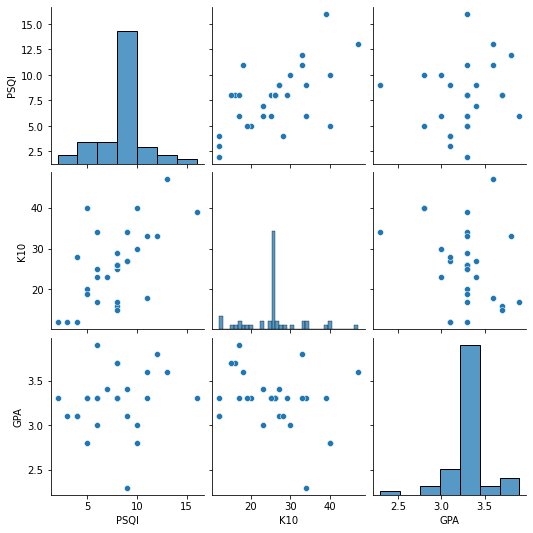

In [11]:
seaborn.pairplot(df)

# Linear Regression

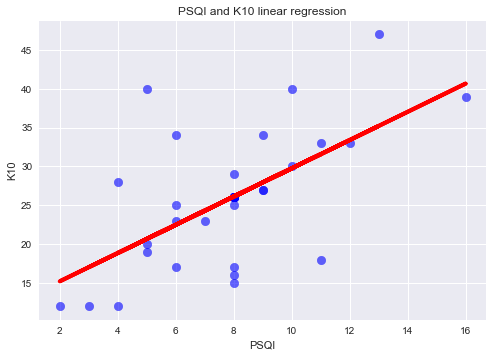

In [12]:
PSQI_list = df['PSQI'].tolist()
K10_list = df['K10'].tolist()

xs = np.array(PSQI_list, dtype=np.float64)
ys = np.array(K10_list, dtype=np.float64)

PSQI_K10 = linear_model.LinearRegression()
PSQI_K10.fit(xs.reshape(-1,1), ys)
regression_line = PSQI_K10.predict(xs.reshape(-1,1))

style.use('seaborn')
plt.scatter(xs, ys, label='Data Points', alpha=0.6, color='blue', s=75)
plt.plot(xs, regression_line, label='Best Fit Line', color='red', linewidth=4)
plt.title('PSQI and K10 linear regression')
plt.xlabel('PSQI')
plt.ylabel('K10')
plt.savefig('foo.png')
plt.show()

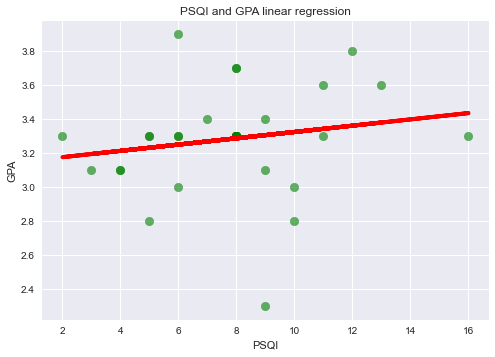

In [13]:
PSQI_list = df['PSQI'].tolist()
GPA_list = df['GPA'].tolist()

xs = np.array(PSQI_list, dtype=np.float64)
ys = np.array(GPA_list, dtype=np.float64)

PSQI_GPA = linear_model.LinearRegression()
PSQI_GPA.fit(xs.reshape(-1,1), ys)
regression_line = PSQI_GPA.predict(xs.reshape(-1,1))

style.use('seaborn')
plt.scatter(xs, ys, label='Data Points', alpha=0.6, color='green', s=75)
plt.plot(xs, regression_line, label='Best Fit Line', color='red', linewidth=4)
plt.title('PSQI and GPA linear regression')
plt.xlabel('PSQI')
plt.ylabel('GPA')
plt.savefig('psqi_gpa.png')
plt.show()

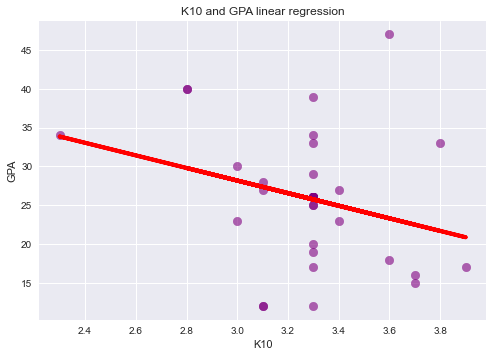

In [14]:
GPA_list = df['GPA'].tolist()
K10_list = df['K10'].tolist()

xs = np.array(GPA_list, dtype=np.float64)
ys = np.array(K10_list, dtype=np.float64)


K10_GPA = linear_model.LinearRegression()
K10_GPA.fit(xs.reshape(-1,1), ys)
regression_line = K10_GPA.predict(xs.reshape(-1,1))

style.use('seaborn')
plt.scatter(xs, ys, label='Data Points', alpha=0.6, color='purple', s=75)
plt.plot(xs, regression_line, label='Best Fit Line', color='red', linewidth=4)
plt.title('K10 and GPA linear regression')
plt.xlabel('K10')
plt.ylabel('GPA')
plt.savefig('k10_gpa.png')
plt.show()